# Lot 1 : Ingestion et Qualité

Ce notebook montre :
1. la lecture d'un fichier FASTQ,
2. le contrôle de qualité et la conversion sélective en FASTA,
3. le découpage en k-mers,
4. l'**histogramme de fréquence des k-mers** pour identifier le taux d'erreur.

In [ ]:
import sys
import os

# On ajoute le dossier parent au chemin pour pouvoir importer src/
sys.path.insert(0, os.path.abspath(".."))

from src.io_sequences import lire_fastq, qualite_moyenne, fastq_vers_fasta, ecrire_fasta
from src.kmers import compter_kmers, kmers_solides, spectre_frequence

import matplotlib.pyplot as plt

# Si le toy dataset n'existe pas encore, on le genere
if not os.path.exists("../data/toy_reads.fastq"):
    from src.generer_toy import generer_toy
    generer_toy()

## 1. Lecture du fichier FASTQ

In [ ]:
reads = lire_fastq("../data/toy_reads.fastq")

print("Nombre de reads lus :", len(reads))
print()
print("Exemple (premier read) :")
identifiant, sequence, qualite = reads[0]
print("  identifiant :", identifiant)
print("  sequence    :", sequence)
print("  qualite     :", qualite)
print("  longueur    :", len(sequence), "bases")

Nombre de reads lus : 2000

Exemple (premier read) :
  identifiant : read_0
  sequence    : CGAATAGGGATATAGGCTACGACATGTGCGGCGACCCTTGCGACAGTGAC
  qualite     : IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
  longueur    : 50 bases


## 2. Contrôle de qualité et conversion sélective en FASTA

On calcule la qualité moyenne (score Phred) de chaque read et on ne garde
que ceux qui dépassent un seuil. C'est la conversion **sélective** FASTQ -> FASTA.

Reads gardes apres filtre qualite (>= 30 ) : 2000
Fichier FASTA ecrit : ../data/toy_reads.fasta


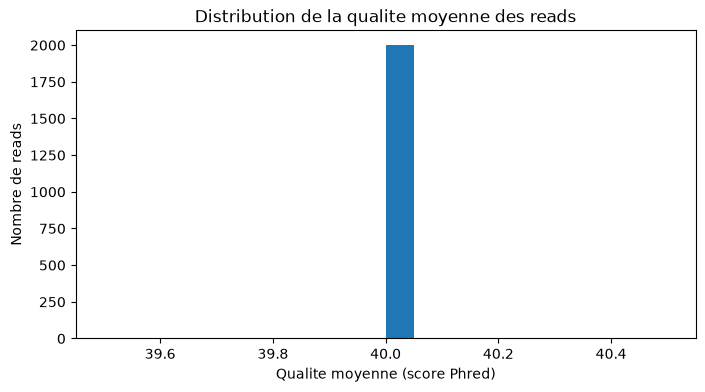

In [ ]:
seuil_qualite = 30

reads_fasta = fastq_vers_fasta(reads, seuil_qualite=seuil_qualite)
print("Reads gardes apres filtre qualite (>=", seuil_qualite, ") :", len(reads_fasta))

# On sauvegarde le resultat en FASTA
ecrire_fasta("../data/toy_reads.fasta", reads_fasta)
print("Fichier FASTA ecrit : ../data/toy_reads.fasta")

# Distribution des qualites moyennes
qualites = []
for identifiant, sequence, qualite in reads:
    qualites.append(qualite_moyenne(qualite))

plt.figure(figsize=(8, 4))
plt.hist(qualites, bins=20)
plt.title("Distribution de la qualite moyenne des reads")
plt.xlabel("Qualite moyenne (score Phred)")
plt.ylabel("Nombre de reads")
plt.show()

## 3. Découpage en k-mers et histogramme de fréquence

On compte tous les k-mers. Le **spectre de fréquence** (fréquence des fréquences)
permet d'identifier les erreurs : les k-mers issus d'erreurs de séquençage
apparaissent très peu souvent (pic à gauche), alors que les vrais k-mers
apparaissent plus souvent.

Nombre de k-mers distincts (k = 21 ) : 7997


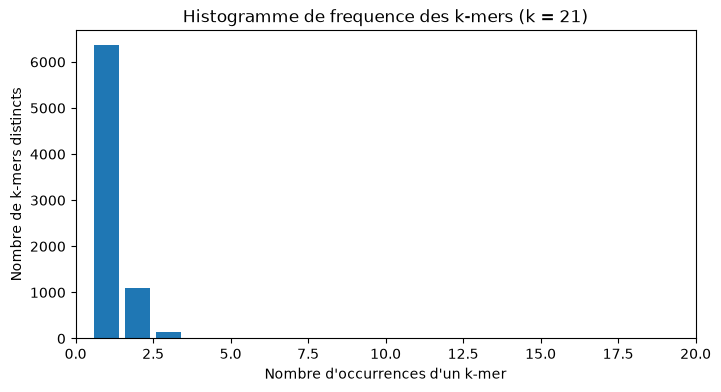

Lecture : le pic a gauche (occurrences = 1) correspond surtout aux erreurs.


In [ ]:
k = 21  # taille des k-mers (parametrable)

comptage = compter_kmers(reads, k)
print("Nombre de k-mers distincts (k =", k, ") :", len(comptage))

spectre = spectre_frequence(comptage)

# On prepare les donnees pour l'histogramme
occurrences = sorted(spectre.keys())
nb_kmers = []
for occ in occurrences:
    nb_kmers.append(spectre[occ])

plt.figure(figsize=(8, 4))
plt.bar(occurrences, nb_kmers)
plt.title("Histogramme de frequence des k-mers (k = " + str(k) + ")")
plt.xlabel("Nombre d'occurrences d'un k-mer")
plt.ylabel("Nombre de k-mers distincts")
plt.xlim(0, 20)
plt.show()

print("Lecture : le pic a gauche (occurrences = 1) correspond surtout aux erreurs.")

In [ ]:
# On choisit un seuil pour separer les k-mers "solides" des erreurs
seuil = 2
solides = kmers_solides(comptage, seuil)
print("Nombre de k-mers solides (occurrences >", seuil, ") :", len(solides))
print("Ces k-mers solides serviront au Lot 3 (assemblage).")

Nombre de k-mers solides (occurrences > 2 ) : 534
Ces k-mers solides serviront au Lot 3 (assemblage).
